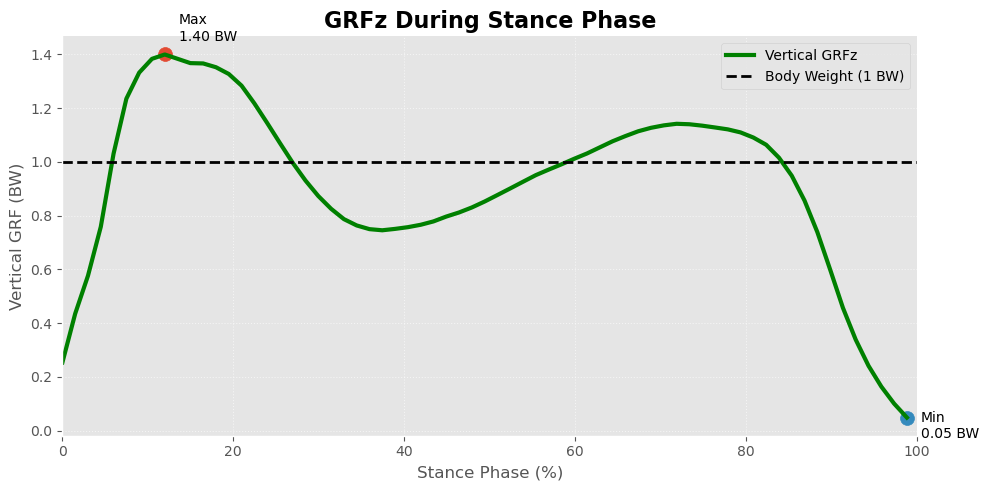

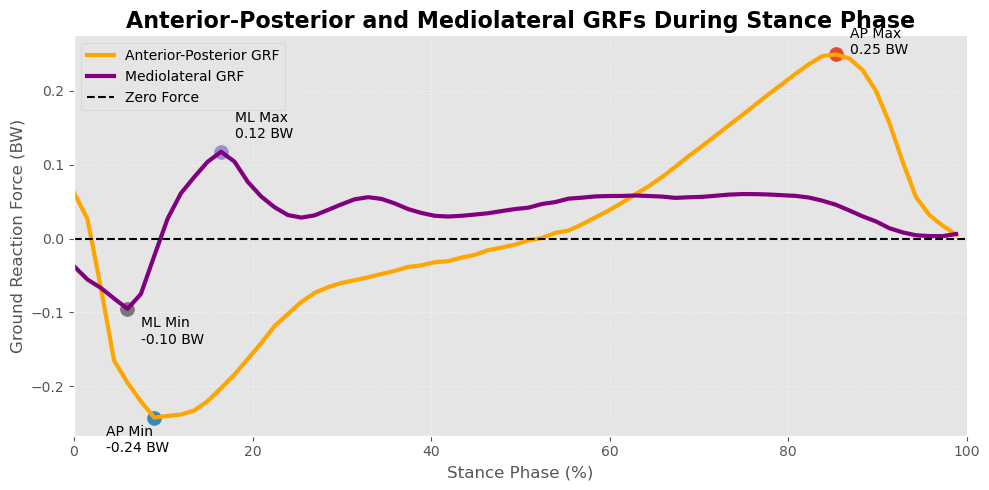

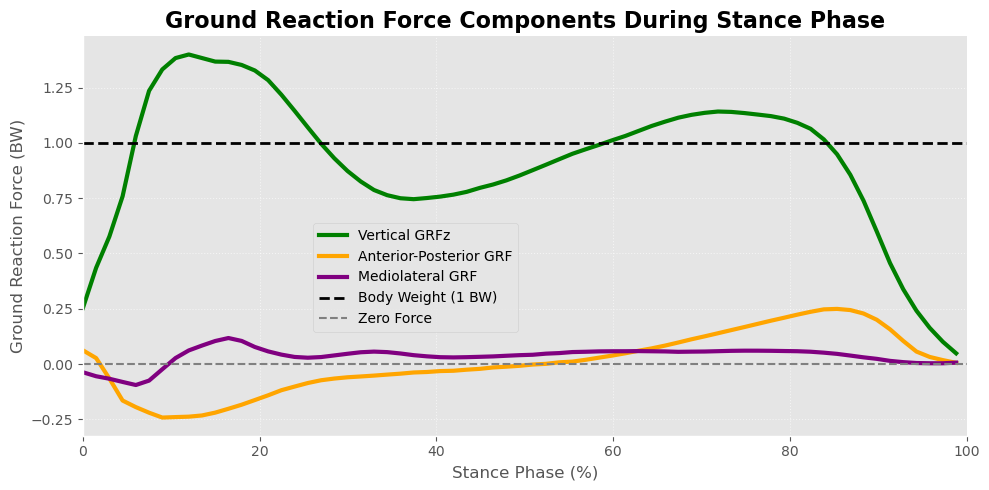

GRFz Max: 1.40 BW
GRFz Min: 0.05 BW
AP Max: 0.25 BW
AP Min: -0.24 BW
ML Max: 0.12 BW
ML Min: -0.10 BW
Toe-off: 60.2% gait cycle


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Metadata

metadata = {
    "frame_number": 114,
    "first_frame": 336,
    "point_frequency": 100,
    "analog_frequency": 100,
    "bw": 78
}

events = {
    "LHS_start": 3.35,
    "LHS_end": 4.48,
    "RHS": 3.91,
    "LTO": 4.03,
}


# Read Excel

df = pd.read_excel("Walk_002.xlsx", header=None)

# Extract data

time = pd.to_numeric(df.iloc[126:238, 0], errors="coerce").reset_index(drop=True)

force_x = pd.to_numeric(df.iloc[126:238, 4], errors="coerce").reset_index(drop=True)
force_y = pd.to_numeric(df.iloc[126:238, 5], errors="coerce").reset_index(drop=True)
force_z = pd.to_numeric(df.iloc[126:238, 6], errors="coerce").reset_index(drop=True)


# Time Normalisation to full gait cycle

time_norm = ((time - time.iloc[0]) / (time.iloc[-1] - time.iloc[0])) * 100

# Force Normalisation to Body Weight

body_weight_newtons = metadata["bw"] * 9.81

# Coordinate convention:
# X = mediolateral
# Y = anterior-posterior
# Z = vertical
# X and Y are inverted to match the chosen graph convention.

force_bw_ml = -force_x / body_weight_newtons
force_bw_ap = -force_y / body_weight_newtons
force_bw_z = force_z / body_weight_newtons

# Toe-Off Position

toe_off = (
    (events["LTO"] - events["LHS_start"]) /
    (events["LHS_end"] - events["LHS_start"])
) * 100

# Crop to stance phase only

stance_mask = time_norm <= toe_off

time_stance = time_norm[stance_mask].reset_index(drop=True)

force_ml_stance = force_bw_ml[stance_mask].reset_index(drop=True)
force_ap_stance = force_bw_ap[stance_mask].reset_index(drop=True)
force_z_stance = force_bw_z[stance_mask].reset_index(drop=True)

# Normalise stance phase to 0–100%
time_stance_norm = (time_stance / toe_off) * 100

# Max / Min Indices

grfz_max_idx = force_z_stance.idxmax()
grfz_min_idx = force_z_stance.idxmin()

ap_max_idx = force_ap_stance.idxmax()
ap_min_idx = force_ap_stance.idxmin()

ml_max_idx = force_ml_stance.idxmax()
ml_min_idx = force_ml_stance.idxmin()

# Plot 1: Vertical GRFz during stance

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_stance_norm,
    force_z_stance,
    linewidth=3,
    color="green",
    label="Vertical GRFz"
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=2,
    color="black",
    label="Body Weight (1 BW)"
)

# GRFz max
ax.scatter(
    time_stance_norm.iloc[grfz_max_idx],
    force_z_stance.iloc[grfz_max_idx],
    s=100
)

ax.annotate(
    f"Max\n{force_z_stance.iloc[grfz_max_idx]:.2f} BW",
    (
        time_stance_norm.iloc[grfz_max_idx],
        force_z_stance.iloc[grfz_max_idx]
    ),
    xytext=(10, 10),
    textcoords="offset points"
)

# GRFz min
ax.scatter(
    time_stance_norm.iloc[grfz_min_idx],
    force_z_stance.iloc[grfz_min_idx],
    s=100
)

ax.annotate(
    f"Min\n{force_z_stance.iloc[grfz_min_idx]:.2f} BW",
    (
        time_stance_norm.iloc[grfz_min_idx],
        force_z_stance.iloc[grfz_min_idx]
    ),
    xytext=(10, -15),
    textcoords="offset points"
)

ax.set_title(
    "GRFz During Stance Phase",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Stance Phase (%)", fontsize=12)
ax.set_ylabel("Vertical GRF (BW)", fontsize=12)

ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()

# Plot 2: AP and ML GRFs during stance

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_stance_norm,
    force_ap_stance,
    linewidth=3,
    color="orange",
    label="Anterior-Posterior GRF"
)

ax.plot(
    time_stance_norm,
    force_ml_stance,
    linewidth=3,
    color="purple",
    label="Mediolateral GRF"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Zero Force"
)

# AP max
ax.scatter(
    time_stance_norm.iloc[ap_max_idx],
    force_ap_stance.iloc[ap_max_idx],
    s=100
)

ax.annotate(
    f"AP Max\n{force_ap_stance.iloc[ap_max_idx]:.2f} BW",
    (
        time_stance_norm.iloc[ap_max_idx],
        force_ap_stance.iloc[ap_max_idx]
    ),
    xytext=(10, 0),
    textcoords="offset points"
)

# AP min
ax.scatter(
    time_stance_norm.iloc[ap_min_idx],
    force_ap_stance.iloc[ap_min_idx],
    s=100
)

ax.annotate(
    f"AP Min\n{force_ap_stance.iloc[ap_min_idx]:.2f} BW",
    (
        time_stance_norm.iloc[ap_min_idx],
        force_ap_stance.iloc[ap_min_idx]
    ),
    xytext=(-35, -25),
    textcoords="offset points"
)

# ML max
ax.scatter(
    time_stance_norm.iloc[ml_max_idx],
    force_ml_stance.iloc[ml_max_idx],
    s=100
)

ax.annotate(
    f"ML Max\n{force_ml_stance.iloc[ml_max_idx]:.2f} BW",
    (
        time_stance_norm.iloc[ml_max_idx],
        force_ml_stance.iloc[ml_max_idx]
    ),
    xytext=(10, 10),
    textcoords="offset points"
)

# ML min
ax.scatter(
    time_stance_norm.iloc[ml_min_idx],
    force_ml_stance.iloc[ml_min_idx],
    s=100
)

ax.annotate(
    f"ML Min\n{force_ml_stance.iloc[ml_min_idx]:.2f} BW",
    (
        time_stance_norm.iloc[ml_min_idx],
        force_ml_stance.iloc[ml_min_idx]
    ),
    xytext=(10, -25),
    textcoords="offset points"
)

ax.set_title(
    "Anterior-Posterior and Mediolateral GRFs During Stance Phase",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Stance Phase (%)", fontsize=12)
ax.set_ylabel("Ground Reaction Force (BW)", fontsize=12)

ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()

# Plot 3: Combined GRF Components

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_stance_norm,
    force_z_stance,
    linewidth=3,
    color="green",
    label="Vertical GRFz"
)

ax.plot(
    time_stance_norm,
    force_ap_stance,
    linewidth=3,
    color="orange",
    label="Anterior-Posterior GRF"
)

ax.plot(
    time_stance_norm,
    force_ml_stance,
    linewidth=3,
    color="purple",
    label="Mediolateral GRF"
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=2,
    color="black",
    label="Body Weight (1 BW)"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    color="grey",
    label="Zero Force"
)

ax.set_title(
    "Ground Reaction Force Components During Stance Phase",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Stance Phase (%)", fontsize=12)
ax.set_ylabel("Ground Reaction Force (BW)", fontsize=12)

ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.5, 0.55)
)

plt.tight_layout()
plt.show()

# Metrics:

print(f"GRFz Max: {force_z_stance.max():.2f} BW")
print(f"GRFz Min: {force_z_stance.min():.2f} BW")

print(f"AP Max: {force_ap_stance.max():.2f} BW")
print(f"AP Min: {force_ap_stance.min():.2f} BW")

print(f"ML Max: {force_ml_stance.max():.2f} BW")
print(f"ML Min: {force_ml_stance.min():.2f} BW")

print(f"Toe-off: {toe_off:.1f}% gait cycle")